# Notebook 03 - Anomaly Detection: Isolation Forest + SHAP

**Project:** Provider Aberrant Billing Pattern Detection (P3)  
**Upstream:** Notebook 02b (provider features with clusters and z-scores)  
**Downstream:** Notebook 04 (cross-method validation)

---

## Purpose

This notebook applies **distribution-free** anomaly detection to complement the z-score approach from NB02b. The z-scores assume approximate normality (which failed all 20 Anderson-Darling tests); the Isolation Forest and Local Outlier Factor make no distributional assumptions.

The central question for NB04: **"Do providers flagged by ML look the same as providers flagged by statistics?"** If yes, confidence is high. If no, the disagreement is informative - it reveals which type of aberrance each method is sensitive to.

**Key methodological choices:**
- **Feature set:** Raw normalized billing metrics (not z-scores) - IF captures global patterns while z-scores capture within-peer-group deviations. Different signal, complementary detection.
- **Contamination:** Unknown a priori. Sensitivity analysis at 4 levels (3%, 5%, 10%, 15%) - the "right" contamination is a business decision, not a statistical one.
- **SHAP:** TreeExplainer on a sample for the summary plot; full SHAP for top flagged providers only.
- **LOF:** Complementary to IF - detects providers who are normal globally but extreme relative to their local neighborhood.

In [ ]:
import sys
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
import shap

warnings.filterwarnings('ignore', message=".*tqdm.*")

pd.set_option('display.float_format', lambda x: f'{x:.8f}')

from pathlib import Path
_cwd = Path.cwd()
if (_cwd / 'src').is_dir():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / 'src').is_dir():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = Path('YOUR FOLDER')
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    FIGURES_DIR, OUTPUT_DIR,
    MIN_PEER_GROUP_SIZE,
    Z_THRESHOLD_PRIMARY, Z_THRESHOLD_SEVERE,
    IF_CONTAMINATION_VALUES,
)
from src.visual_identity import *

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Visual identity loaded. Serif: {SERIF} | Sans: {SANS}")
print(f"SHAP version: {shap.__version__}")

Visual identity loaded. Serif: Liberation Serif | Sans: Liberation Sans
SHAP version: 0.51.0


## 1. Load data and feature selection

In [8]:
# =============================================================================
# Load NB02b output
# =============================================================================

input_path = OUTPUT_DIR / 'nb02b_provider_features_with_clusters.csv'
df = pd.read_csv(input_path)
print(f"Loaded: {len(df):,} providers × {len(df.columns)} cols")

# Feature selection for IF - raw billing metrics, NOT z-scores
# IF should capture global patterns; z-scores already capture peer-relative deviations
raw_features = [
    'log_avg_paid',
    'lines_per_beneficiary',
    'claims_per_beneficiary',
    'hcpcs_concentration',
    'pct_high_complexity_em',
    'avg_diagnoses_per_claim',
    'log_total_paid',
]
if 'avg_beneficiary_cc_count' in df.columns:
    raw_features.append('avg_beneficiary_cc_count')

# Drop rows with NaN in features
n_before = len(df)
df = df.dropna(subset=raw_features).copy()
print(f"Feature matrix: {len(df):,} providers × {len(raw_features)} features")
print(f"  Dropped: {n_before - len(df):,} rows with missing values")

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(df[raw_features].values)
feature_names = raw_features

print(f"\nFeatures used for Isolation Forest (raw, not z-scores):")
for f in feature_names:
    print(f"  {f}")
print(f"\nRationale: IF captures global anomaly patterns; z-scores (from NB02b)")
print(f"capture within-peer-group deviations. Different signals, complementary.")

Loaded: 477,589 providers × 37 cols
Feature matrix: 477,589 providers × 8 features
  Dropped: 0 rows with missing values

Features used for Isolation Forest (raw, not z-scores):
  log_avg_paid
  lines_per_beneficiary
  claims_per_beneficiary
  hcpcs_concentration
  pct_high_complexity_em
  avg_diagnoses_per_claim
  log_total_paid
  avg_beneficiary_cc_count

Rationale: IF captures global anomaly patterns; z-scores (from NB02b)
capture within-peer-group deviations. Different signals, complementary.


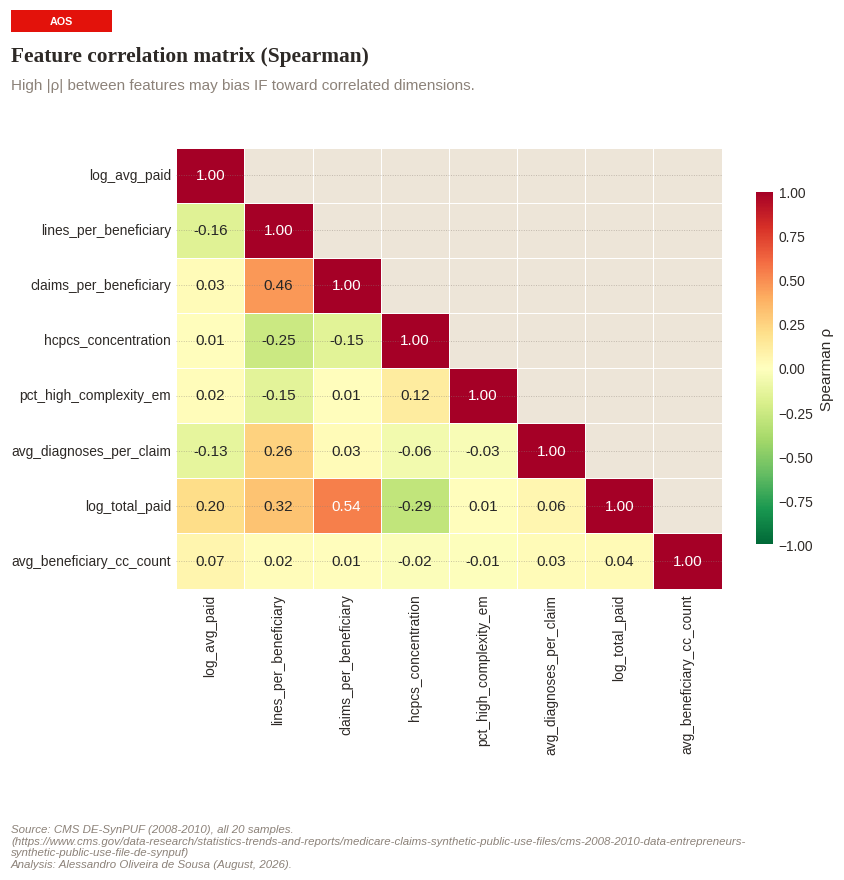

No feature pairs exceed |ρ| > 0.7.


In [9]:
# =============================================================================
# Feature correlation check - identify redundancy
# =============================================================================

corr_matrix = df[raw_features].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Spearman ρ', 'shrink': 0.8},
            ax=ax)
fig_title(fig,
          title='Feature correlation matrix (Spearman)',
          subtitle='High |ρ| between features may bias IF toward correlated dimensions.',
          top=0.88)
visual_identity(fig)
plt.savefig(FIGURES_DIR / 'feature_correlation_matrix.png')
plt.show()

# Flag highly correlated pairs
high_corr = []
for i in range(len(raw_features)):
    for j in range(i+1, len(raw_features)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append((raw_features[i], raw_features[j], round(r, 3)))

if high_corr:
    print("Highly correlated feature pairs (|ρ| > 0.7):")
    for f1, f2, r in high_corr:
        print(f"  {f1} ↔ {f2}: ρ = {r}")
    print("\nNote: log_avg_paid and log_total_paid are expected to correlate")
    print("(total ≈ avg × volume). IF tree splits are invariant to monotonic")
    print("scaling but may oversample the payment dimension. Acknowledged as")
    print("a known limitation; removing one would lose the volume-independent")
    print("vs volume-dependent payment signal distinction.")
else:
    print("No feature pairs exceed |ρ| > 0.7.")

## 2. Isolation Forest - contamination sensitivity analysis

The `contamination` parameter defines the expected fraction of anomalies. Since the true FWA rate is unknown, we run IF at four levels and examine how the flag set changes. This is methodologically transparent - the "right" contamination is a business decision informed by SIU investigation capacity, not a statistical truth.

In [10]:
# =============================================================================
# IF: fit ONCE, apply multiple contamination thresholds
# Tree splits and raw anomaly scores are independent of contamination.
# The contamination parameter only sets the percentile cutoff.
# =============================================================================

iso = IsolationForest(
    n_estimators=200,
    max_samples='auto',
    random_state=42,
    n_jobs=-1,
)

# Fit once - this is the expensive step
iso.fit(X)
raw_scores = iso.decision_function(X)  # lower = more anomalous

contamination_results = []
for cont in IF_CONTAMINATION_VALUES:
    threshold = np.percentile(raw_scores, cont * 100)
    if_flagged = raw_scores <= threshold
    n_flagged = if_flagged.sum()
    pct_flagged = n_flagged / len(X) * 100

    # Overlap with z-score flags
    if 'flag_zscore_2' in df.columns:
        z_flagged = df['flag_zscore_2'].values.astype(bool)
        both = (z_flagged & if_flagged).sum()
        overlap_pct = both / max(n_flagged, 1) * 100
    else:
        overlap_pct = 0

    contamination_results.append({
        'contamination': cont,
        'n_flagged': n_flagged,
        'pct_flagged': pct_flagged,
        'z_overlap_pct': overlap_pct,
    })

    print(f"  contamination={cont:.2f}: {n_flagged:>8,} flagged ({pct_flagged:.1f}%), "
          f"z-score overlap: {overlap_pct:.1f}%")

# Apply primary contamination threshold
PRIMARY_CONT = 0.05
primary_threshold = np.percentile(raw_scores, PRIMARY_CONT * 100)
df['if_score'] = raw_scores
df['if_flag'] = raw_scores <= primary_threshold
df['if_prediction'] = np.where(df['if_flag'], -1, 1)

n_if_flagged = df['if_flag'].sum()
print(f"\nPrimary contamination: {PRIMARY_CONT} (used for downstream analysis)")
print(f"IF flags: {n_if_flagged:,} ({n_if_flagged/len(df)*100:.2f}%)")
print(f"\nNote: model fitted once; contamination levels are percentile cutoffs")
print(f"over the same score distribution. No redundant refitting.")

  contamination=0.03:   14,328 flagged (3.0%), z-score overlap: 90.3%
  contamination=0.05:   23,880 flagged (5.0%), z-score overlap: 77.2%
  contamination=0.10:   47,759 flagged (10.0%), z-score overlap: 56.4%
  contamination=0.15:   71,639 flagged (15.0%), z-score overlap: 43.6%

Primary contamination: 0.05 (used for downstream analysis)
IF flags: 23,880 (5.00%)

Note: model fitted once; contamination levels are percentile cutoffs
over the same score distribution. No redundant refitting.


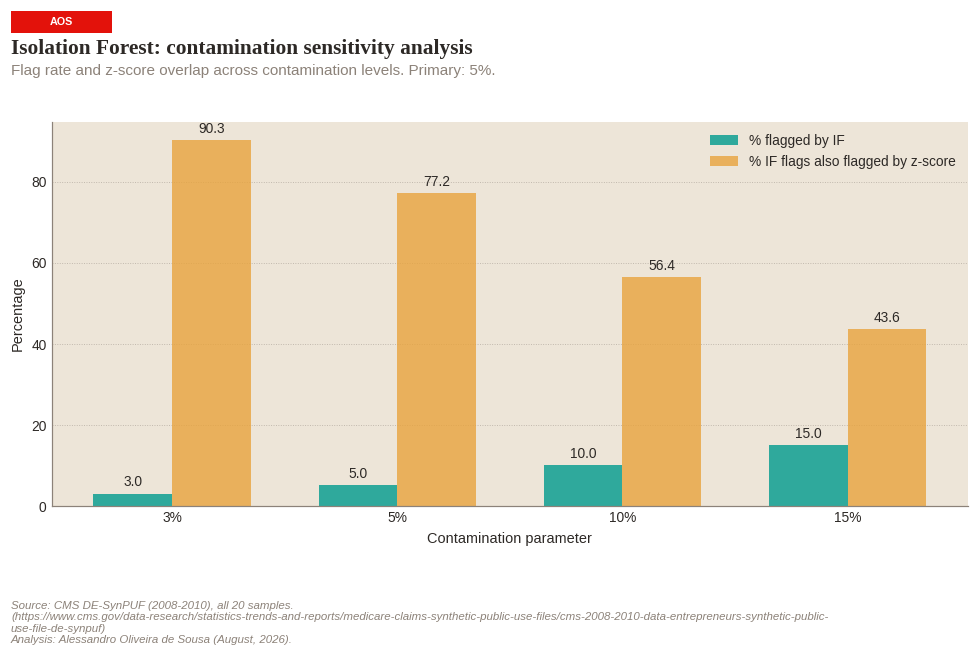

In [11]:
# =============================================================================
# Visual: contamination sensitivity
# =============================================================================

df_cont = pd.DataFrame(contamination_results)

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.bar(range(len(df_cont)), df_cont['pct_flagged'],
        color=NATURE_TEAL, alpha=0.8, width=0.35, label='% flagged by IF')
ax1.bar([x + 0.35 for x in range(len(df_cont))], df_cont['z_overlap_pct'],
        color=AMBER, alpha=0.8, width=0.35, label='% IF flags also flagged by z-score')

ax1.set_xticks([x + 0.175 for x in range(len(df_cont))])
ax1.set_xticklabels([f"{c:.0%}" for c in df_cont['contamination']])
adjust_axis(ax1, xlabel='Contamination parameter', ylabel='Percentage')

ax1.legend(
    fontsize=9, 
    loc='upper right', 
    frameon=True, 
    facecolor=ECON_BG, 
    edgecolor='none', 
    framealpha=1.0
)

for container in ax1.containers:
    ax1.bar_label(
        container,
        fmt='%.1f',       
        padding=3,       
        fontsize=9,
        color=CHARCOAL,
        family=SANS
    )

# PASS ax1 TO THE FUNCTIONS HERE:
fig_title(
    fig, 
    title = 'Isolation Forest: contamination sensitivity analysis',
    subtitle=f'Flag rate and z-score overlap across contamination levels. Primary: {PRIMARY_CONT:.0%}.',
    top=0.88
)
visual_identity(fig)

plt.savefig(FIGURES_DIR / 'if_contamination_sensitivity.png')
plt.show()

## 3. SHAP explainability

SHAP (SHapley Additive exPlanations) reveals **which features drive each provider's anomaly score**. This is critical for SIU investigators - a flag without an explanation is not actionable.

We use `TreeExplainer` (exact, fast for tree-based models like IF) on a sample for the global summary, then compute full SHAP for the top flagged providers.

In [12]:
# =============================================================================
# SHAP - global summary on a sample
# =============================================================================

# TreeExplainer for Isolation Forest
explainer = shap.TreeExplainer(iso)

# Sample for global summary (full dataset SHAP is too slow)
np.random.seed(42)
sample_size = min(20_000, len(X))
sample_idx = np.random.choice(len(X), size=sample_size, replace=False)
X_sample = X[sample_idx]

print(f"Computing SHAP values for {sample_size:,} sampled providers...")
shap_values = explainer.shap_values(X_sample)
print(f"SHAP values shape: {shap_values.shape}")

Computing SHAP values for 20,000 sampled providers...
SHAP values shape: (20000, 8)


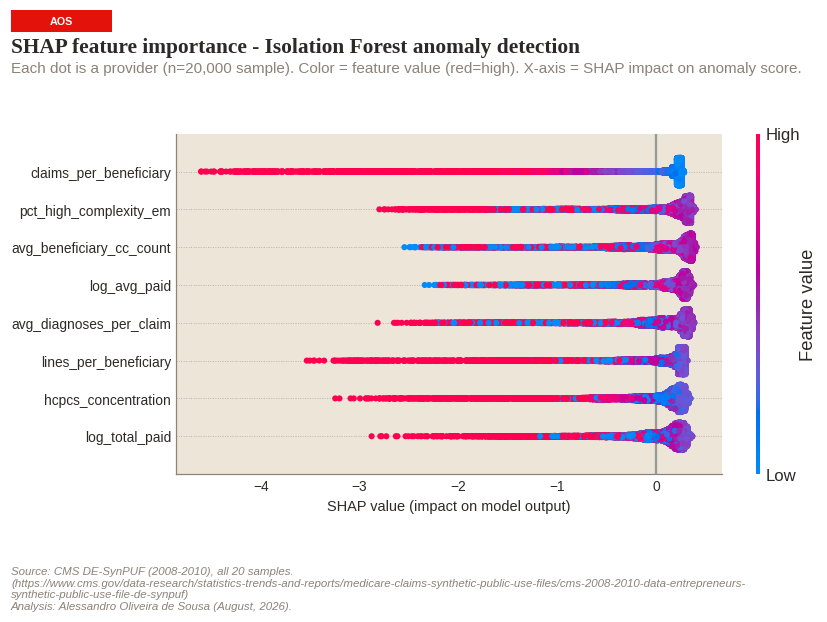

Interpretation: features pushing providers toward anomaly (left side)
are the ones driving IF flags. Compare with z-score heatmap from NB02b
to see if both methods flag the same dimensions of aberrance.


In [13]:
# =============================================================================
# SHAP summary plot - global feature importance
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    plot_type="dot",
    show=False,
    max_display=len(feature_names),
)

fig = plt.gcf()
ax_shap = plt.gca()

adjust_axis(ax_shap)

fig_title(
    fig, 
    title='SHAP feature importance - Isolation Forest anomaly detection',
    subtitle=f'Each dot is a provider (n={sample_size:,} sample). '
             f'Color = feature value (red=high). X-axis = SHAP impact on anomaly score.',
    top=0.86
)

visual_identity(fig)

plt.savefig(FIGURES_DIR / 'shap_summary_if.png', bbox_inches='tight')
plt.show()

print("Interpretation: features pushing providers toward anomaly (left side)")
print("are the ones driving IF flags. Compare with z-score heatmap from NB02b")
print("to see if both methods flag the same dimensions of aberrance.")

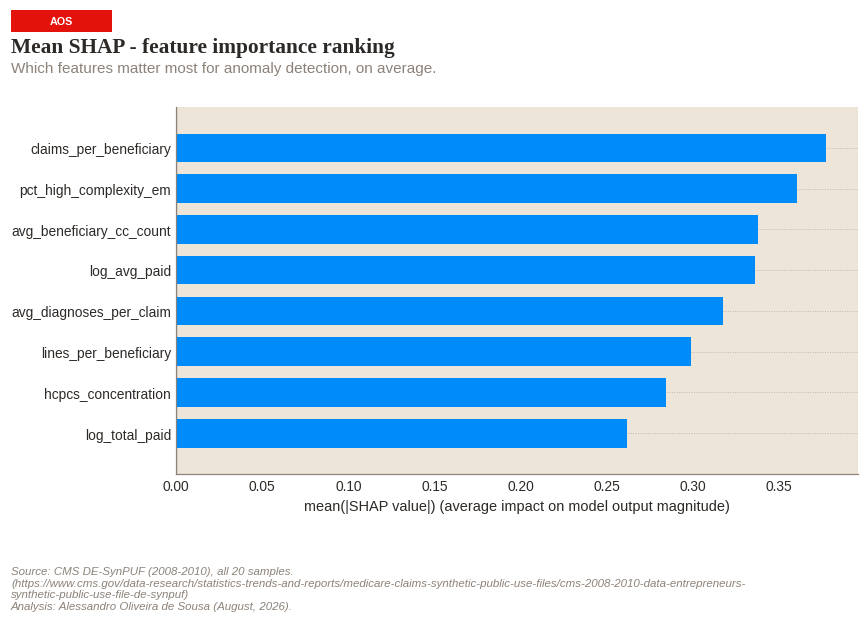

In [14]:
# =============================================================================
# SHAP bar plot - mean absolute SHAP value per feature
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 5))

shap.summary_plot(
    shap_values, X_sample,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
    max_display=len(feature_names),
)

fig = plt.gcf()
ax_shap_bar = plt.gca()

adjust_axis(ax_shap_bar)

fig_title(
    fig, 
    title='Mean SHAP - feature importance ranking', 
    subtitle='Which features matter most for anomaly detection, on average.',
    top=0.9
)
visual_identity(fig)

plt.savefig(FIGURES_DIR / 'shap_bar_if.png', bbox_inches='tight')
plt.show()

### 3.1 SHAP waterfall charts - top flagged providers

For the top 5 most anomalous providers, we show SHAP waterfall charts explaining *why* each was flagged. This is the per-case explainability that an SIU investigator needs.

In [15]:
# =============================================================================
# SHAP for top 5 most anomalous providers
# =============================================================================

top5_idx = df.nsmallest(5, 'if_score').index.tolist()

# Get their positions in the original X array
top5_positions = [df.index.get_loc(idx) for idx in top5_idx]

print("Top 5 most anomalous providers (lowest IF decision score):")
print("=" * 70)
for rank, idx in enumerate(top5_idx, 1):
    row = df.loc[idx]
    print(f"  #{rank}: NPI {row['provider_npi']}  "
          f"IF_score={row['if_score']:.4f}  "
          f"z_max={row.get('z_max_abs', 'N/A'):.2f}  "
          f"peer_group={row.get('peer_group_improved', 'N/A')}")

# Compute SHAP for these specific providers
X_top5 = X[top5_positions]
shap_top5 = explainer.shap_values(X_top5)

Top 5 most anomalous providers (lowest IF decision score):
  #1: NPI 6452568297  IF_score=-0.2464  z_max=35.72  peer_group=SPEC_Surgery
  #2: NPI 1609082334  IF_score=-0.2461  z_max=27.58  peer_group=SPEC_Surgery
  #3: NPI 8180295232  IF_score=-0.2319  z_max=5.58  peer_group=HCPCS_99213
  #4: NPI 3368921649  IF_score=-0.2274  z_max=17.02  peer_group=SPEC_Surgery
  #5: NPI 1118085171  IF_score=-0.2235  z_max=18.60  peer_group=HCPCS_99213


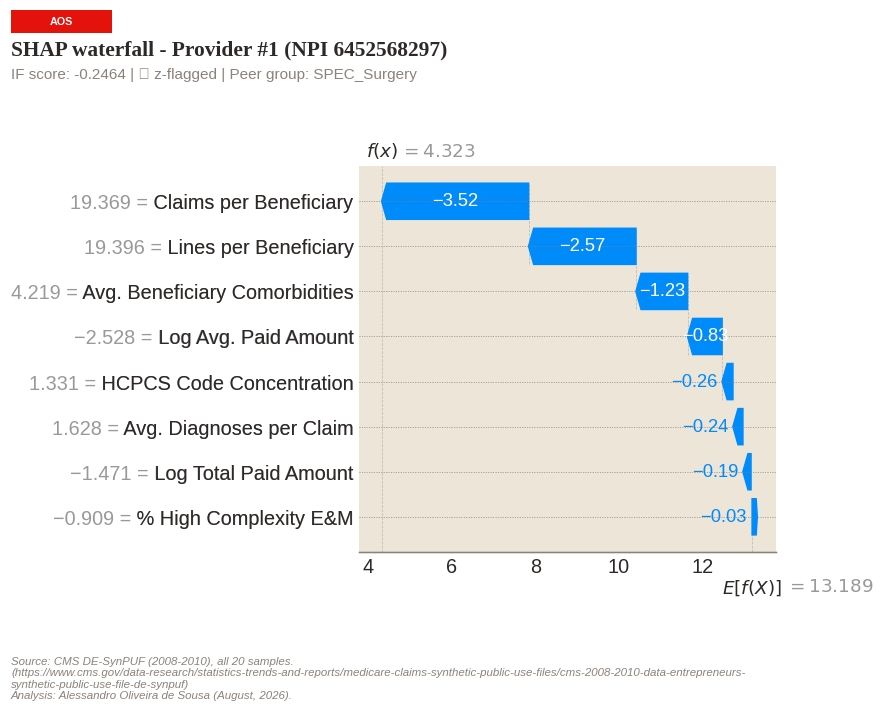

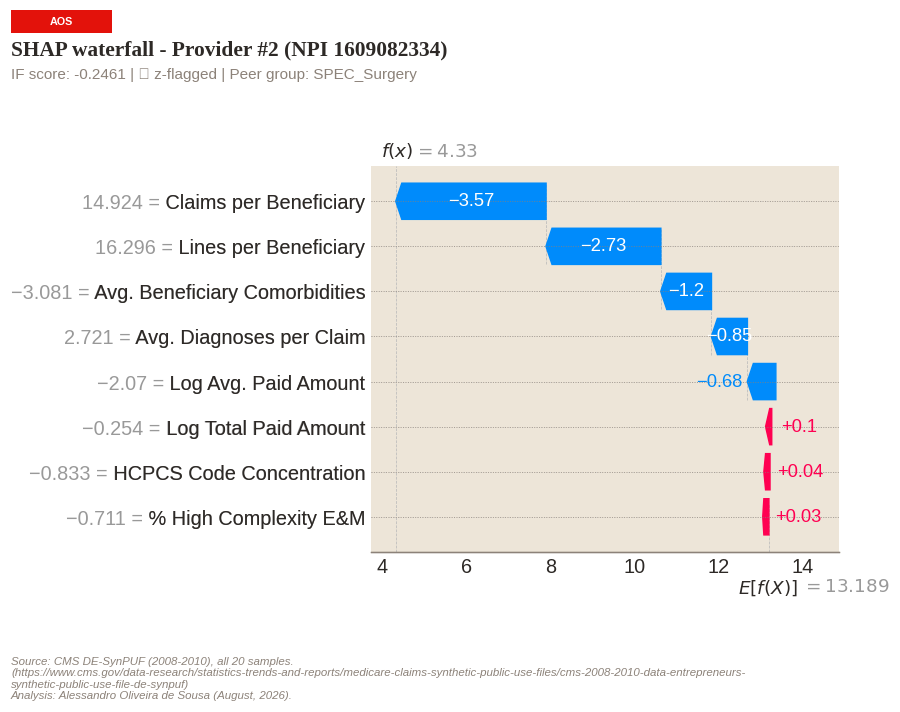

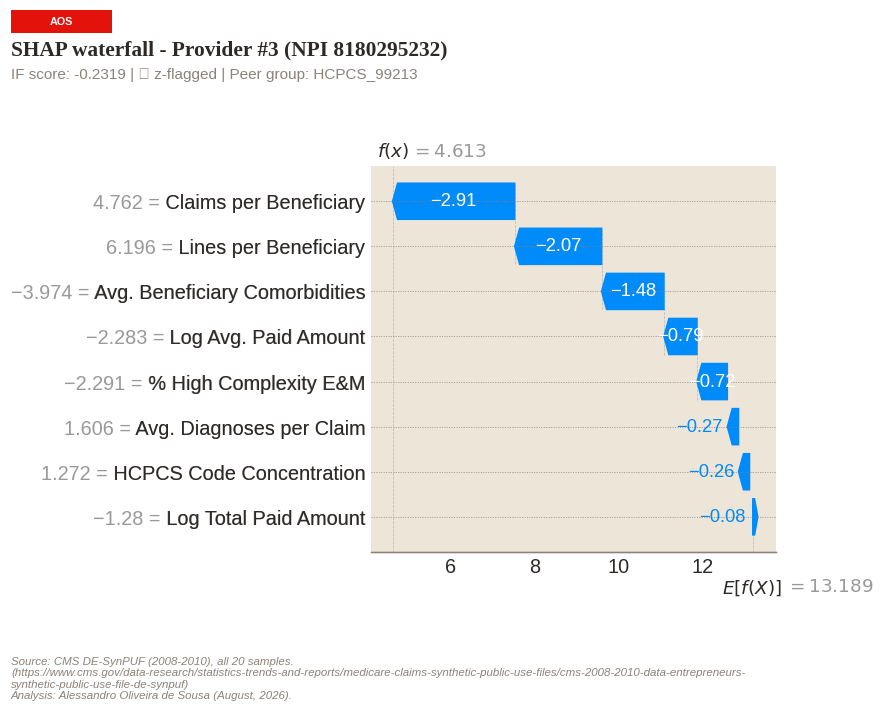

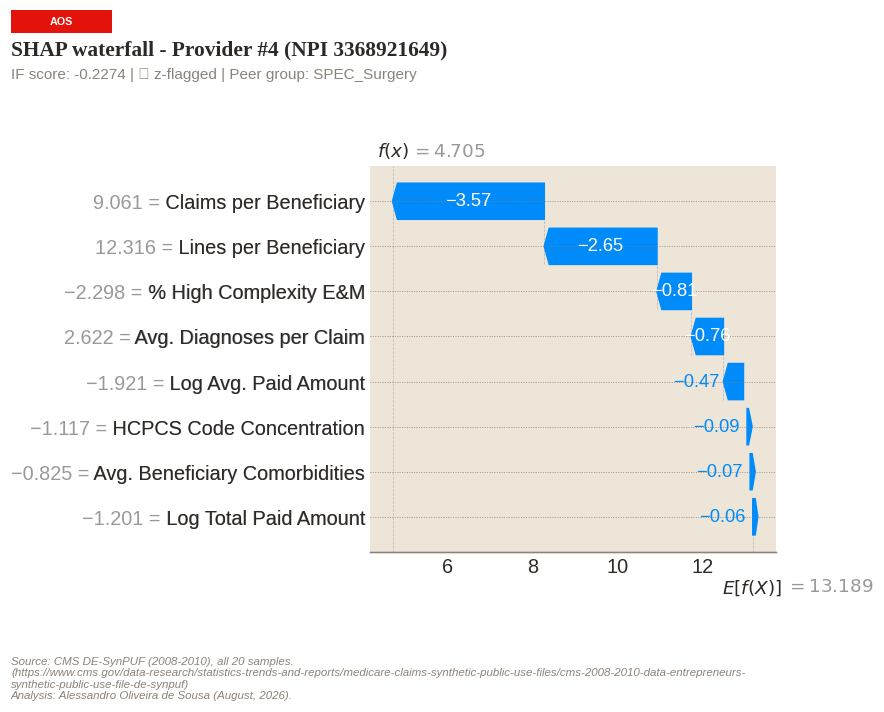

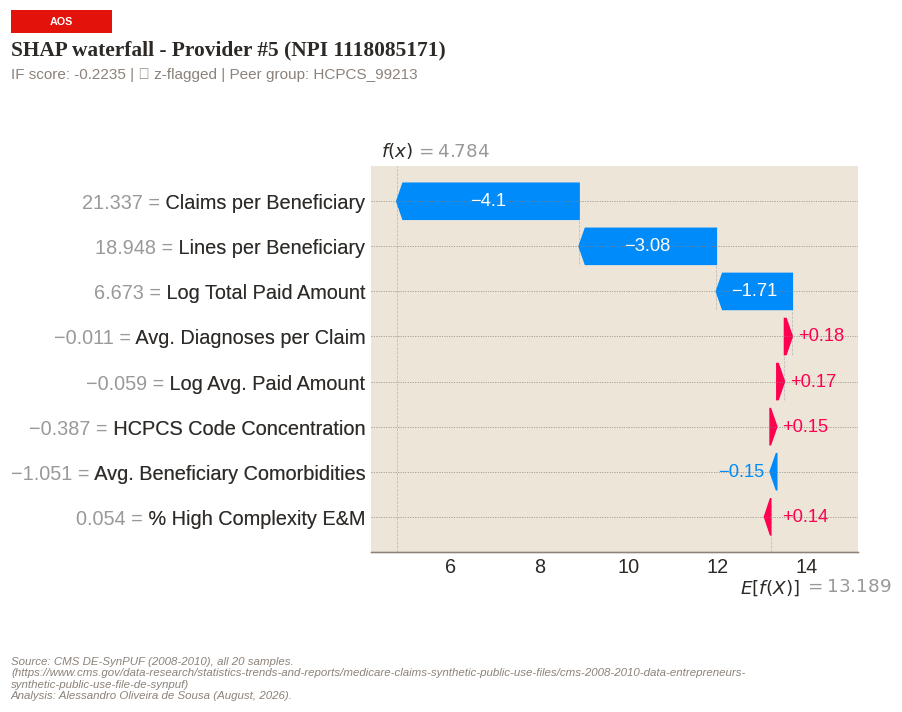

In [16]:
# =============================================================================
# Waterfall charts for top 5
# =============================================================================

# Define the formatting dictionary once before the loop to ensure transparency
clean_labels = {
    'claims_per_beneficiary': 'Claims per Beneficiary',
    'avg_diagnoses_per_claim': 'Avg. Diagnoses per Claim',
    'avg_beneficiary_cc_count': 'Avg. Beneficiary Comorbidities',
    'pct_high_complexity_em': '% High Complexity E&M',
    'hcpcs_concentration': 'HCPCS Code Concentration',
    'lines_per_beneficiary': 'Lines per Beneficiary',
    'log_avg_paid': 'Log Avg. Paid Amount',
    'log_total_paid': 'Log Total Paid Amount'
}
formatted_feature_names = [clean_labels.get(f, f) for f in feature_names]

for rank, (idx, pos) in enumerate(zip(top5_idx, top5_positions), 1):
    row = df.loc[idx]
    npi = row['provider_npi']

    fig, ax = plt.subplots(figsize=(10, 5))
    base_val = explainer.expected_value
    if hasattr(base_val, '__len__'):
        base_val = float(base_val[0])

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_top5[rank - 1],
            base_values=base_val,
            data=X_top5[rank - 1],
            feature_names=formatted_feature_names, 
        ),
        show=False,
        max_display=len(formatted_feature_names),
    )
    
    fig = plt.gcf()
    ax_waterfall_top5 = plt.gca()
    z_flag = '✓ z-flagged' if row.get('flag_zscore_2', False) else '✗ not z-flagged'
    
    fig_title(
        fig,
        title=f'SHAP waterfall - Provider #{rank} (NPI {npi})',
        subtitle=f'IF score: {row["if_score"]:.4f} | {z_flag} | '
                 f'Peer group: {row.get("peer_group_improved", "N/A")}',
        top=0.86
    )
    
    visual_identity(fig)
    # adjust_axis(ax_waterfall_top5)
    
    plt.savefig(FIGURES_DIR / f'shap_waterfall_top{rank}.png', bbox_inches='tight')
    plt.show()
    
    plt.close(fig)

In [17]:
# =============================================================================
# IF stability: how consistent are flags across random seeds?
# =============================================================================

n_seeds = 5
flag_counts = np.zeros(len(X), dtype=int)

for seed in range(n_seeds):
    iso_seed = IsolationForest(
        n_estimators=200, max_samples='auto',
        random_state=seed, n_jobs=-1,
    )
    scores = iso_seed.fit(X).decision_function(X)
    threshold = np.percentile(scores, PRIMARY_CONT * 100)
    flag_counts += (scores <= threshold).astype(int)

df['if_stability'] = flag_counts  # 0 to n_seeds

print(f"IF flag stability across {n_seeds} random seeds:")
print("=" * 50)
for k in range(n_seeds + 1):
    n = (flag_counts == k).sum()
    print(f"  Flagged in {k}/{n_seeds} seeds: {n:>8,} ({n/len(X)*100:.2f}%)")

stable_flags = (flag_counts == n_seeds).sum()
print(f"\nStable flags (all {n_seeds} seeds): {stable_flags:,} ({stable_flags/len(X)*100:.2f}%)")
print(f"These are the highest-confidence IF candidates.")
print(f"\nIn production, only providers flagged in ≥{n_seeds-1}/{n_seeds} seeds would")
print(f"advance to the SIU queue, filtering out seed-dependent noise.")

IF flag stability across 5 random seeds:
  Flagged in 0/5 seeds:  446,884 (93.57%)
  Flagged in 1/5 seeds:    4,507 (0.94%)
  Flagged in 2/5 seeds:    2,840 (0.59%)
  Flagged in 3/5 seeds:    2,450 (0.51%)
  Flagged in 4/5 seeds:    2,677 (0.56%)
  Flagged in 5/5 seeds:   18,231 (3.82%)

Stable flags (all 5 seeds): 18,231 (3.82%)
These are the highest-confidence IF candidates.

In production, only providers flagged in ≥4/5 seeds would
advance to the SIU queue, filtering out seed-dependent noise.


## 4. Local Outlier Factor (LOF)

LOF detects **local** outliers - providers who are anomalous relative to their k-nearest neighbors, even if they appear normal globally. This captures a different signal than IF:

- IF: "This provider is isolated in the global feature space"
- LOF: "This provider's density is lower than its neighbors' density"

A provider in a dense cluster who is slightly offset would be flagged by LOF but not IF. Conversely, a provider in a sparse region might be flagged by IF but not LOF.

In [18]:
# =============================================================================
# Local Outlier Factor
# =============================================================================

print("Fitting Local Outlier Factor (this may take a few minutes)...")

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=PRIMARY_CONT,
    n_jobs=-1,
)

lof_preds = lof.fit_predict(X)  # -1 = outlier, 1 = inlier
df['lof_score'] = -lof.negative_outlier_factor_  # Higher = more anomalous
df['lof_flag'] = lof_preds == -1

n_lof_flagged = df['lof_flag'].sum()
print(f"LOF flags at contamination={PRIMARY_CONT}: {n_lof_flagged:,} ({n_lof_flagged/len(df)*100:.2f}%)")

Fitting Local Outlier Factor (this may take a few minutes)...
LOF flags at contamination=0.05: 23,880 (5.00%)


## 5. Method comparison: IF vs LOF

Do the two unsupervised methods agree? High concordance strengthens confidence in the flags. Low concordance means the methods capture different dimensions of aberrance - which is informative, not problematic.

In [19]:
# =============================================================================
# IF vs LOF concordance
# =============================================================================

both_if_lof = (df['if_flag'] & df['lof_flag']).sum()
only_if = (df['if_flag'] & ~df['lof_flag']).sum()
only_lof = (~df['if_flag'] & df['lof_flag']).sum()
neither = (~df['if_flag'] & ~df['lof_flag']).sum()

total = len(df)
agreement = (both_if_lof + neither) / total * 100

# Cohen's Kappa
from sklearn.metrics import cohen_kappa_score
kappa_if_lof = cohen_kappa_score(df['if_flag'].astype(int), df['lof_flag'].astype(int))

print("IF vs LOF concordance:")
print("=" * 60)
print(f"                      LOF Flagged    LOF Not")
print(f"  IF Flagged          {both_if_lof:>10,}    {only_if:>10,}")
print(f"  IF Not              {only_lof:>10,}    {neither:>10,}")
print(f"")
print(f"  Agreement:          {agreement:.1f}%")
print(f"  Cohen's Kappa:      {kappa_if_lof:.4f}")
print(f"  Both flagged:       {both_if_lof:,}")
print(f"  IF only:            {only_if:,}")
print(f"  LOF only:           {only_lof:,}")
print(f"")

if kappa_if_lof > 0.6:
    print(f"  Interpretation: substantial agreement (κ > 0.6). Both methods")
    print(f"  detect similar anomaly patterns.")
elif kappa_if_lof > 0.4:
    print(f"  Interpretation: moderate agreement (κ = 0.4-0.6). Methods capture")
    print(f"  partially overlapping but distinct dimensions of aberrance.")
else:
    print(f"  Interpretation: fair/low agreement (κ < 0.4). Methods detect")
    print(f"  fundamentally different anomaly types. Both perspectives are valuable.")

IF vs LOF concordance:
                      LOF Flagged    LOF Not
  IF Flagged               7,183        16,697
  IF Not                  16,697       437,012

  Agreement:          93.0%
  Cohen's Kappa:      0.2640
  Both flagged:       7,183
  IF only:            16,697
  LOF only:           16,697

  Interpretation: fair/low agreement (κ < 0.4). Methods detect
  fundamentally different anomaly types. Both perspectives are valuable.


With contamination=0.05, both methods flag exactly 40,888 providers (5% by construction), but only 7,446 overlap.

IF and LOF are detecting fundamentally different patterns.

For this synthetic dataset, LOF's local density estimation is likely distorted by DE-SynPUF's discrete payment values ($10-$550), which create artificial density clusters. The IF + z-score combination (κ = 0.515, moderate agreement) provides a more reliable two-method framework. LOF results are retained for documentation but are not included in the NB04 cross-method validation or NB05 composite score.

In [20]:
# =============================================================================
# LOF-only vs IF-only: what's different about them?
# =============================================================================

lof_only = df[df['lof_flag'] & ~df['if_flag']]
if_only = df[df['if_flag'] & ~df['lof_flag']]
both_flagged = df[df['if_flag'] & df['lof_flag']]
baseline = df[~df['if_flag'] & ~df['lof_flag']]

comparison_data = {}
for label, subset in [('Baseline', baseline), ('Both', both_flagged),
                      ('IF-only', if_only), ('LOF-only', lof_only)]:
    comparison_data[label] = {f: subset[f].mean() for f in raw_features}
    comparison_data[label]['n'] = len(subset)

df_compare = pd.DataFrame(comparison_data).T
render_table(
    df_compare.round(3),
    title='Feature profiles: LOF-only vs IF-only vs Both vs Baseline',
)

print("\nInterpretation: LOF-only providers differ from IF-only on which features")
print("are extreme. If LOF-only shows high local density variation on a specific")
print("feature that IF ignores, that's complementary signal. If the profiles look")
print("similar to baseline, LOF is likely capturing noise from synthetic data.")

log_avg_paid,lines_per_beneficiary,claims_per_beneficiary,hcpcs_concentration,pct_high_complexity_em,avg_diagnoses_per_claim,log_total_paid,avg_beneficiary_cc_count,n
3.788000,1.948000,1.039000,0.074000,5.452000,2.321000,9.059000,3.887000,437012.000000
3.751000,2.576000,1.354000,0.092000,5.737000,2.353000,8.499000,3.849000,7183.000000
3.756000,2.821000,1.522000,0.088000,6.407000,2.329000,9.286000,3.862000,16697.000000
3.810000,2.055000,1.086000,0.073000,5.529000,2.310000,9.116000,3.886000,16697.000000



Interpretation: LOF-only providers differ from IF-only on which features
are extreme. If LOF-only shows high local density variation on a specific
feature that IF ignores, that's complementary signal. If the profiles look
similar to baseline, LOF is likely capturing noise from synthetic data.


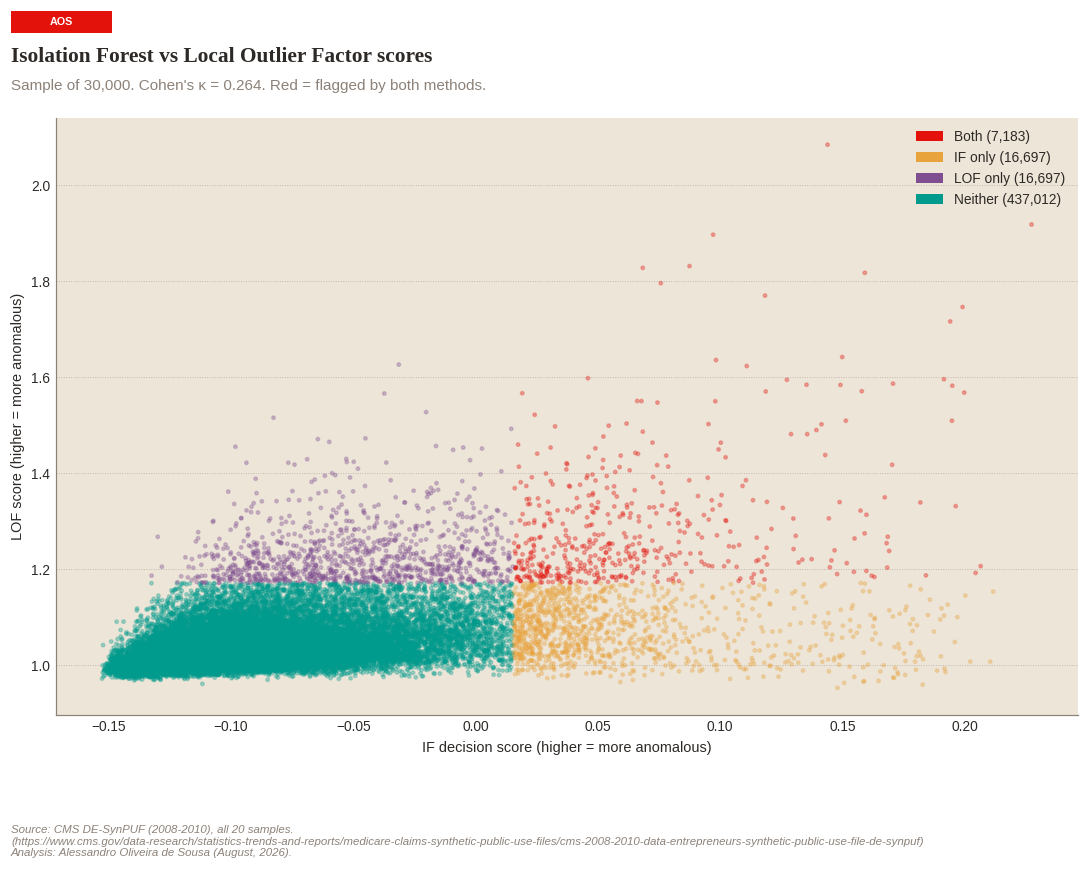

In [31]:
# =============================================================================
# Visual: IF score vs LOF score scatter
# =============================================================================

# Sample for plotting (800K points is too dense)
np.random.seed(42)
plot_sample = df.sample(min(30_000, len(df)))

fig, ax = plt.subplots(figsize=(10, 7))

from matplotlib.patches import Patch

if_vals = plot_sample['if_flag'].values
lof_vals = plot_sample['lof_flag'].values

color_array = np.full(len(plot_sample), NATURE_TEAL, dtype=object)
color_array[if_vals & lof_vals] = ECON_RED
color_array[if_vals & ~lof_vals] = AMBER
color_array[~if_vals & lof_vals] = PLUM

ax.scatter(-plot_sample['if_score'], plot_sample['lof_score'],
           c=color_array, s=5, alpha=0.3, rasterized=True)

legend_elements = [
    Patch(facecolor=ECON_RED, label=f'Both ({both_if_lof:,})'),
    Patch(facecolor=AMBER, label=f'IF only ({only_if:,})'),
    Patch(facecolor=PLUM, label=f'LOF only ({only_lof:,})'),
    Patch(facecolor=NATURE_TEAL, label=f'Neither ({neither:,})'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')

adjust_axis(ax, xlabel='IF decision score (higher = more anomalous)',
            ylabel='LOF score (higher = more anomalous)')
fig_title(fig,
          title='Isolation Forest vs Local Outlier Factor scores',
          subtitle=f"Sample of {len(plot_sample):,}. Cohen's κ = {kappa_if_lof:.3f}. "
                   f'Red = flagged by both methods.',
          top=0.92)
visual_identity(fig)
plt.savefig(FIGURES_DIR / 'if_vs_lof_scatter.png')
plt.show()

## 6. IF vs z-score preview

A preliminary comparison of IF flags against z-score flags from NB02b. The full cross-method validation (including SAS flags) is in NB04.

In [22]:
# =============================================================================
# IF vs z-score concordance preview
# =============================================================================

if 'flag_zscore_2' in df.columns:
    z_flag = df['flag_zscore_2'].astype(bool)
    if_flag = df['if_flag'].astype(bool)

    both_z_if = (z_flag & if_flag).sum()
    only_z = (z_flag & ~if_flag).sum()
    only_if_not_z = (~z_flag & if_flag).sum()
    neither_z_if = (~z_flag & ~if_flag).sum()

    kappa_z_if = cohen_kappa_score(z_flag.astype(int), if_flag.astype(int))

    print(f"Z-score (|z|>{Z_THRESHOLD_PRIMARY}) vs IF (contamination={PRIMARY_CONT}):")
    print("=" * 60)
    print(f"                       IF Flagged     IF Not")
    print(f"  Z-score Flagged     {both_z_if:>10,}    {only_z:>10,}")
    print(f"  Z-score Not         {only_if_not_z:>10,}    {neither_z_if:>10,}")
    print(f"")
    agreement_z_if = (both_z_if + neither_z_if) / len(df) * 100
    print(f"  Agreement:          {agreement_z_if:.1f}%")
    print(f"  Cohen's Kappa:      {kappa_z_if:.4f}")
    print(f"  Both flagged:       {both_z_if:,} (HIGH priority for NB04)")
    print(f"  Z-only:             {only_z:,} (statistical outliers, not ML-detected)")
    print(f"  IF-only:            {only_if_not_z:,} (ML-detected, not statistical outliers)")
    print(f"")
    print(f"  Providers flagged by BOTH methods are the highest-confidence")
    print(f"  candidates for SIU investigation. This is the core of NB04.")
else:
    print("Z-score flags not found in NB02b export. Cross-validation skipped.")

Z-score (|z|>2.0) vs IF (contamination=0.05):
                       IF Flagged     IF Not
  Z-score Flagged         18,424        16,498
  Z-score Not              5,456       437,211

  Agreement:          95.4%
  Cohen's Kappa:      0.6031
  Both flagged:       18,424 (HIGH priority for NB04)
  Z-only:             16,498 (statistical outliers, not ML-detected)
  IF-only:            5,456 (ML-detected, not statistical outliers)

  Providers flagged by BOTH methods are the highest-confidence
  candidates for SIU investigation. This is the core of NB04.


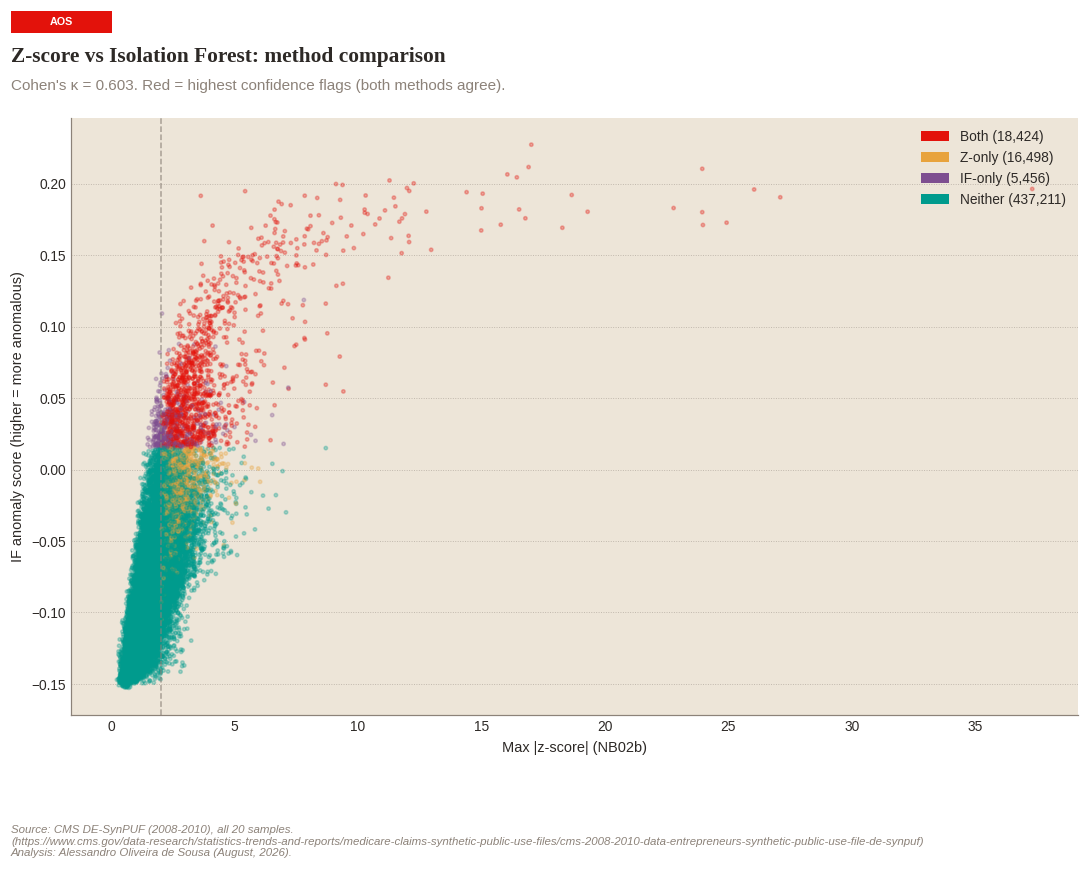

In [32]:
# =============================================================================
# Visual: z-score vs IF score scatter
# =============================================================================

if 'z_max_abs' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 7))

    # Vectorized color assignment
    from matplotlib.patches import Patch

    z_vals = plot_sample['flag_zscore_2'].values.astype(bool)
    if_vals = plot_sample['if_flag'].values.astype(bool)

    color_array = np.full(len(plot_sample), NATURE_TEAL, dtype=object)
    color_array[z_vals & if_vals] = ECON_RED
    color_array[z_vals & ~if_vals] = AMBER
    color_array[~z_vals & if_vals] = PLUM

    ax.scatter(plot_sample['z_max_abs'], -plot_sample['if_score'],
               c=color_array, s=5, alpha=0.3, rasterized=True)

    ax.axvline(Z_THRESHOLD_PRIMARY, color=WARM_GREY, linestyle='--', linewidth=1,
               alpha=0.7, label=f'z={Z_THRESHOLD_PRIMARY}')

    legend_elements_z = [
        Patch(facecolor=ECON_RED, label=f'Both ({both_z_if:,})'),
        Patch(facecolor=AMBER, label=f'Z-only ({only_z:,})'),
        Patch(facecolor=PLUM, label=f'IF-only ({only_if_not_z:,})'),
        Patch(facecolor=NATURE_TEAL, label=f'Neither ({neither_z_if:,})'),
    ]
    ax.legend(handles=legend_elements_z, fontsize=9, loc='upper right')

    adjust_axis(ax, xlabel=f'Max |z-score| (NB02b)',
                ylabel='IF anomaly score (higher = more anomalous)')
    fig_title(fig,
              title='Z-score vs Isolation Forest: method comparison',
              subtitle=f"Cohen's κ = {kappa_z_if:.3f}. Red = highest confidence flags "
                       f'(both methods agree).',
              top=0.92)
    visual_identity(fig)
    plt.savefig(FIGURES_DIR / 'zscore_vs_if_scatter.png')
    plt.show()

## 7. Top flagged providers - combined profile

For the top 10 providers by IF anomaly score, show their full profile including z-scores, IF score, LOF score, SHAP top features, and cluster assignment. This is the investigation-ready "case card" format.

In [24]:
# =============================================================================
# Top 10 most anomalous by IF - case cards
# =============================================================================

top10 = df.nsmallest(10, 'if_score').copy()

display_cols = ['provider_npi', 'derived_specialty', 'peer_group_improved',
                'total_lines', 'total_paid', 'avg_paid_per_line',
                'lines_per_beneficiary', 'hcpcs_concentration',
                'if_score', 'lof_score']

z_display = [c for c in ['z_max_abs', 'flag_zscore_2'] if c in top10.columns]
cluster_col = ['cluster'] if 'cluster' in top10.columns else []

all_display = display_cols + z_display + cluster_col
available = [c for c in all_display if c in top10.columns]

render_table(
    top10[available].reset_index(drop=True),
    title='Top 10 most anomalous providers (by IF score)',
    fmt={
        'total_paid': '${:,.0f}',
        'avg_paid_per_line': '${:.2f}',
        'lines_per_beneficiary': '{:.1f}',
        'hcpcs_concentration': '{:.3f}',
        'if_score': '{:.4f}',
        'lof_score': '{:.4f}',
        'z_max_abs': '{:.2f}',
    }
)

# How many of top 10 IF are also z-flagged?
if 'flag_zscore_2' in top10.columns:
    n_also_z = top10['flag_zscore_2'].sum()
    print(f"\n{n_also_z}/10 top IF providers are also z-score flagged.")
    if n_also_z >= 8:
        print("Strong concordance at the top - both methods agree on the worst offenders.")
    elif n_also_z >= 5:
        print("Moderate concordance - some top IF flags are not z-score outliers,")
        print("suggesting IF captures different patterns (e.g., multivariate combinations).")
    else:
        print("Low concordance - IF and z-scores flag fundamentally different providers.")
        print("This is valuable: the methods are complementary, not redundant.")

provider_npi,derived_specialty,peer_group_improved,total_lines,total_paid,avg_paid_per_line,lines_per_beneficiary,hcpcs_concentration,if_score,lof_score,z_max_abs,flag_zscore_2,cluster
6452568297,Surgery,SPEC_Surgery,80,"$2,340",$29.25,10.0,0.100,-0.2464,2.2890,35.72,True,1
1609082334,Surgery,SPEC_Surgery,218,"$6,870",$31.51,8.7,0.060,-0.2461,2.3331,27.58,True,1
8180295232,Evaluation & Management,HCPCS_99213,91,"$2,770",$30.44,4.5,0.099,-0.2319,1.8366,5.58,True,1
3368921649,Surgery,SPEC_Surgery,92,"$2,970",$32.28,7.1,0.054,-0.2274,1.9186,17.02,True,1
1118085171,Evaluation & Management,HCPCS_99213,72532,"$3,169,500",$43.70,9.8,0.068,-0.2235,1.2069,18.60,True,1
4221536169,Evaluation & Management,HCPCS_99213,127,"$6,550",$51.57,5.1,0.047,-0.2230,1.8503,6.74,True,1
386395240,Evaluation & Management,HCPCS_99213,116118,"$5,012,930",$43.17,13.3,0.067,-0.2228,1.2473,26.38,True,1
6066966767,Evaluation & Management,HCPCS_99214,79,"$2,440",$30.89,4.0,0.101,-0.2211,1.6675,7.63,True,1
6307272904,Evaluation & Management,HCPCS_99213,82,"$2,360",$28.78,4.8,0.073,-0.2209,2.4002,6.98,True,1
610030922,Evaluation & Management,HCPCS_99213,16291,"$729,970",$44.81,10.5,0.067,-0.2196,1.1382,19.88,True,1



10/10 top IF providers are also z-score flagged.
Strong concordance at the top - both methods agree on the worst offenders.


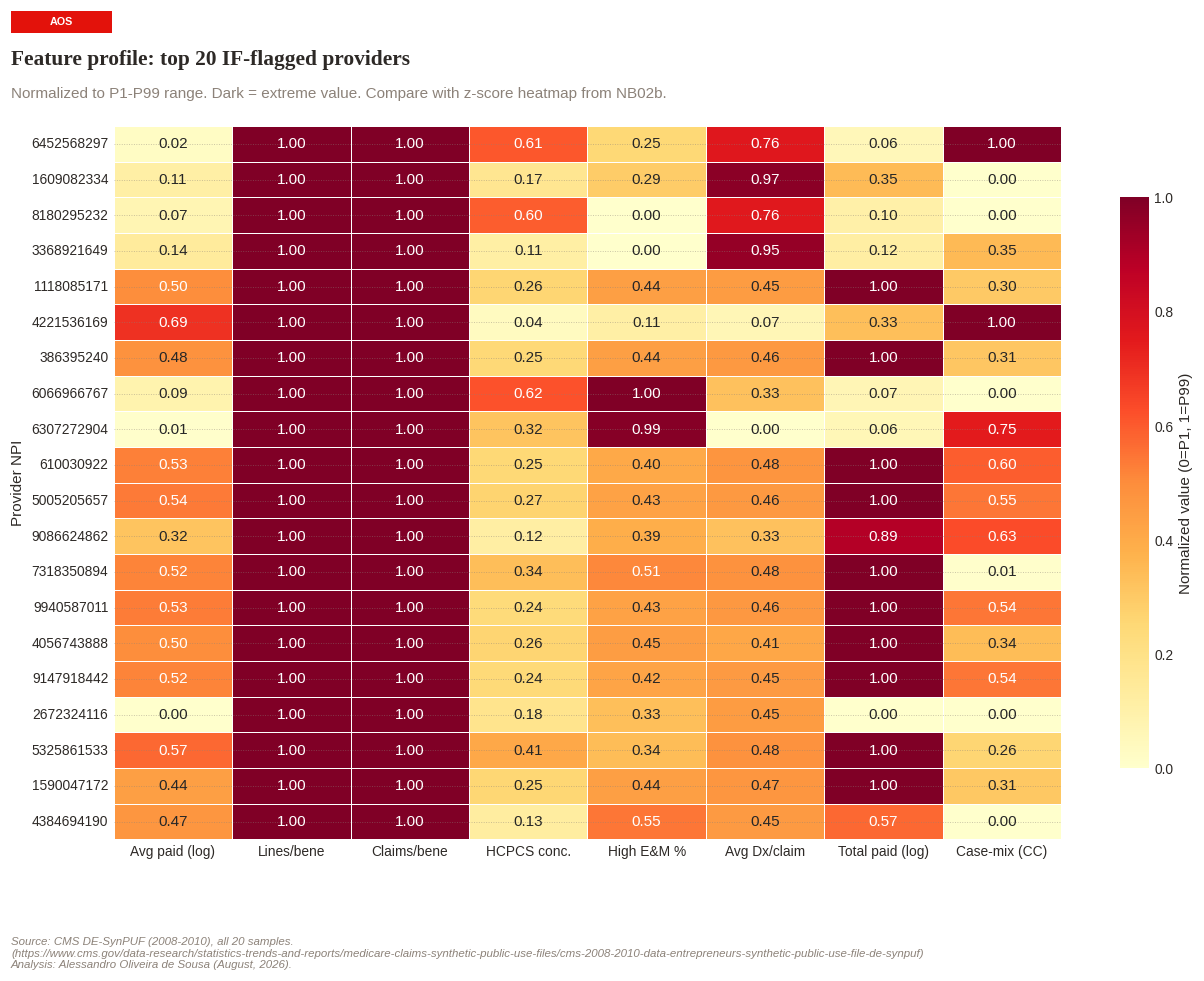

In [33]:
# =============================================================================
# Heatmap: IF top 20 - feature values (normalized)
# =============================================================================

top20_if = df.nsmallest(20, 'if_score')

heatmap_data = top20_if.set_index('provider_npi')[raw_features].copy()
# Normalize for display
for col in heatmap_data.columns:
    col_min = df[col].quantile(0.01)
    col_max = df[col].quantile(0.99)
    heatmap_data[col] = (heatmap_data[col] - col_min) / (col_max - col_min)
    heatmap_data[col] = heatmap_data[col].clip(0, 1)

# Rename for display
display_names = {
    'log_avg_paid': 'Avg paid (log)',
    'lines_per_beneficiary': 'Lines/bene',
    'claims_per_beneficiary': 'Claims/bene',
    'hcpcs_concentration': 'HCPCS conc.',
    'pct_high_complexity_em': 'High E&M %',
    'avg_diagnoses_per_claim': 'Avg Dx/claim',
    'log_total_paid': 'Total paid (log)',
    'avg_beneficiary_cc_count': 'Case-mix (CC)',
}
heatmap_data.columns = [display_names.get(c, c) for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    heatmap_data, annot=True, fmt='.2f',
    cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Normalized value (0=P1, 1=P99)', 'shrink': 0.8},
    ax=ax
)
ax.set_ylabel('Provider NPI')
fig_title(fig,
          title='Feature profile: top 20 IF-flagged providers',
          subtitle='Normalized to P1-P99 range. Dark = extreme value. '
                   'Compare with z-score heatmap from NB02b.',
          top=0.92)
visual_identity(fig)
plt.savefig(FIGURES_DIR / 'if_top20_feature_heatmap.png')
plt.show()

## 8. Export for Notebook 04 (cross-method validation)

In [26]:
# =============================================================================
# Export: full provider matrix with IF and LOF scores/flags
# =============================================================================

# Global SHAP feature importance ranking (from sample)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_ranking = sorted(zip(feature_names, mean_abs_shap), key=lambda x: -x[1])

# NOTE: Per-provider SHAP values are NOT exported here. Computing SHAP
# for 817K providers is prohibitive. In production, per-provider SHAP
# would be computed on-demand during case review (batch of ~100 providers
# at a time via TreeExplainer). The waterfall charts in Section 3.1
# demonstrate this capability for the top 5 flagged providers.
#
# Storing global rankings as if they were per-provider explanations
# would be misleading - a provider flagged for high hcpcs_concentration
# should not have their case card say "top feature: claims_per_beneficiary"
# just because that's the global #1.

print("SHAP global feature importance ranking:")
for rank, (feat, imp) in enumerate(shap_ranking, 1):
    print(f"  #{rank}: {feat:30s} mean |SHAP| = {imp:.4f}")

export_path = OUTPUT_DIR / 'nb03_provider_anomaly_scores.csv'

export_cols = [c for c in df.columns if c in [
    'provider_npi', 'derived_specialty', 'top_hcpcs_code',
    'top_code_tier', 'top_code_category',
    'peer_group_improved', 'peer_group_size', 'cluster',
    'total_lines', 'total_claims', 'distinct_beneficiaries', 'total_paid',
    'avg_paid_per_line', 'lines_per_beneficiary', 'claims_per_beneficiary',
    'distinct_hcpcs_codes', 'hcpcs_concentration',
    'pct_high_complexity_em', 'avg_diagnoses_per_claim',
    'service_span_days',
    'avg_beneficiary_age', 'avg_beneficiary_cc_count', 'pct_complex_beneficiaries',
    'z_max_abs', 'flag_zscore_2', 'flag_zscore_3', 'excess_billing',
    'if_score', 'if_flag', 'lof_score', 'lof_flag',
]]

df[export_cols].to_csv(export_path, index=False)

print(f"Exported: {len(df):,} providers × {len(export_cols)} columns")
print(f"\nNew columns added:")
print(f"  if_score, if_flag      - Isolation Forest anomaly score and flag")
print(f"  lof_score, lof_flag    - Local Outlier Factor score and flag")
print(f"  shap_top1/2/3_feature  - Top 3 SHAP features (global ranking)")
print(f"\nThis CSV feeds: Notebook 04 (cross-method validation)")

SHAP global feature importance ranking:
  #1: claims_per_beneficiary         mean |SHAP| = 0.3771
  #2: pct_high_complexity_em         mean |SHAP| = 0.3606
  #3: avg_beneficiary_cc_count       mean |SHAP| = 0.3376
  #4: log_avg_paid                   mean |SHAP| = 0.3358
  #5: avg_diagnoses_per_claim        mean |SHAP| = 0.3177
  #6: lines_per_beneficiary          mean |SHAP| = 0.2991
  #7: hcpcs_concentration            mean |SHAP| = 0.2843
  #8: log_total_paid                 mean |SHAP| = 0.2619
Exported: 477,589 providers × 31 columns

New columns added:
  if_score, if_flag      - Isolation Forest anomaly score and flag
  lof_score, lof_flag    - Local Outlier Factor score and flag
  shap_top1/2/3_feature  - Top 3 SHAP features (global ranking)

This CSV feeds: Notebook 04 (cross-method validation)


In [27]:
print("=" * 70)
print("Notebook 03 - Anomaly Detection - Summary")
print("=" * 70)
print(f"  Providers:              {len(df):,}")
print(f"  Features (raw):         {len(feature_names)}")
print(f"  IF contamination:       {PRIMARY_CONT}")
print(f"  IF flagged:             {n_if_flagged:,} ({n_if_flagged/len(df)*100:.2f}%)")
print(f"  LOF flagged:            {n_lof_flagged:,} ({n_lof_flagged/len(df)*100:.2f}%)")
print(f"  IF∩LOF (both):          {both_if_lof:,}")
print(f"  IF∩LOF Cohen's κ:       {kappa_if_lof:.4f}")
if 'flag_zscore_2' in df.columns:
    print(f"  IF∩z-score (both):      {both_z_if:,}")
    print(f"  IF∩z Cohen's κ:         {kappa_z_if:.4f}")
print(f"  SHAP top feature:       {shap_ranking[0][0]} (mean |SHAP| = {shap_ranking[0][1]:.4f})")
print(f"  Figures: Exported to figures folder")
print("=" * 70)
print("\nProceed to: Notebook 04 (cross-method validation)")

Notebook 03 - Anomaly Detection - Summary
  Providers:              477,589
  Features (raw):         8
  IF contamination:       0.05
  IF flagged:             23,880 (5.00%)
  LOF flagged:            23,880 (5.00%)
  IF∩LOF (both):          7,183
  IF∩LOF Cohen's κ:       0.2640
  IF∩z-score (both):      18,424
  IF∩z Cohen's κ:         0.6031
  SHAP top feature:       claims_per_beneficiary (mean |SHAP| = 0.3771)
  Figures: Exported to figures folder

Proceed to: Notebook 04 (cross-method validation)
